In [1]:
import Ts.TsMetrics as tsm
import Ts.TsModels as tsmd
import Ts.TsPlots as tsp
import Ts.TsTests as tst
import Ts.TsUtils as tsu
import numpy as np 
import pandas as pd

In [ ]:
# import data 

sales = pd.read_excel("data.xlsx", sheet_name="s4-sales", index_col="time").iloc[:140]
leading = pd.read_excel("data.xlsx", sheet_name="s5-leading_indicator", index_col="time").iloc[:140]
df = pd.concat([sales, leading], axis=1)
df.columns = ["sales", "leading"]

In [5]:
model = tsmd.SARIMAX(
      df["sales"],
      exog=df["leading"],
      order=(0, 1, 1),          # 误差项采用 AR(1)
      trend="c",                # 原始水平截距
      missing="raise",
      distributed_lags={
          "leading":tsmd.RationalLagSpec(
              numerator=0,
              denominator=1,
              delay=3,
          )
      },
  )

result = model.fit(
      method="bfgs",
      maxiter=300,
      cov_type="oim",
      require_convergence=True,
  )

print(result.summary())
# result.plot_impulse_response()
# result.plot_diagnostics()
# result.steady_state_gains

SARIMAX Model Estimation Result
Order: SARIMAX(0, 1, 1)
RDL leading          : numerator [0]; denominator [1]; delay 3; initialization auto -> steady_state
RDL leading gain     : 17.2272; stable=Yes
Active MA Lags     : 1
Likelihood Burn      : 1 (effective n=139)
AR Stationarity    : Not applicable (no AR terms)
MA Invertibility   : Passed (minimum |root| = 2.4852)
Stationarity Enforced  : Yes
Invertibility Enforced : Yes
Optimizer              : bfgs
Converged              : Yes
Observations       : 140
Log-Likelihood     : 1.3387
AIC                : 7.3226
BIC                : 21.9949

Parameter Estimates:
--------------------------------------------------
  intercept                0.0185  (0.0135)  p=0.1710
  ma.L1                   -0.4024  (0.0784)  p=0.0000
  sigma2                   0.0574  (0.0069)  p=0.0000
  rdl.leading.omega.L0     4.7211  (0.0661)  p=0.0000
  rdl.leading.delta.L1     0.7260  (0.0051)  p=0.0000


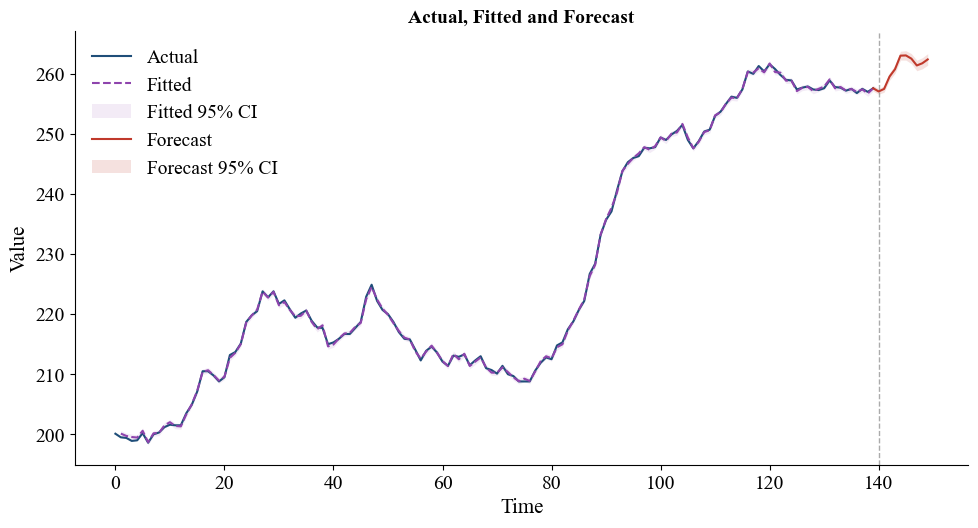

In [ ]:
# predict and forecast
sales_all = pd.read_excel(
      "data.xlsx",
      sheet_name="s4-sales",
      index_col="time",
  ).squeeze()

leading_all = pd.read_excel(
      "data.xlsx",
      sheet_name="s5-leading_indicator",
      index_col="time",
  ).squeeze()

future_leading = (
      leading_all.iloc[140:150]
      .rename("leading")
      .reset_index(drop=True)
  )

forecast = result.predict(
      start=result.nobs,       # 140，即第141期
      end=result.nobs + 9,     # 149，即第150期
      future_exog=future_leading,
  )

fig, ax = forecast.plot(
      ci=True,
      title="Actual, Fitted and Forecast"
  )



  Residual cross-correlation: leading
  S* statistic       : 10.571922
  Chi-square df      : 11
  P-value            : 0.479791
  Maximum lag        : 12
  Effective obs.     : 139
  Transfer parameters: 2
  Pointwise peaks    : None
  H0: residual cross-correlations at lags 0..K are jointly zero
  Conclusion (5%): Cannot reject H0 (no remaining cross-correlation detected)
---------------
     input  s_statistic  df   p_value  reject  nobs  transfer_params
0  leading    10.571922  11  0.479791   False   139                2


(<Figure size 1000x550 with 1 Axes>,
 <Axes: title={'center': 'leading'}, xlabel='Lag', ylabel='Residual CCF'>)

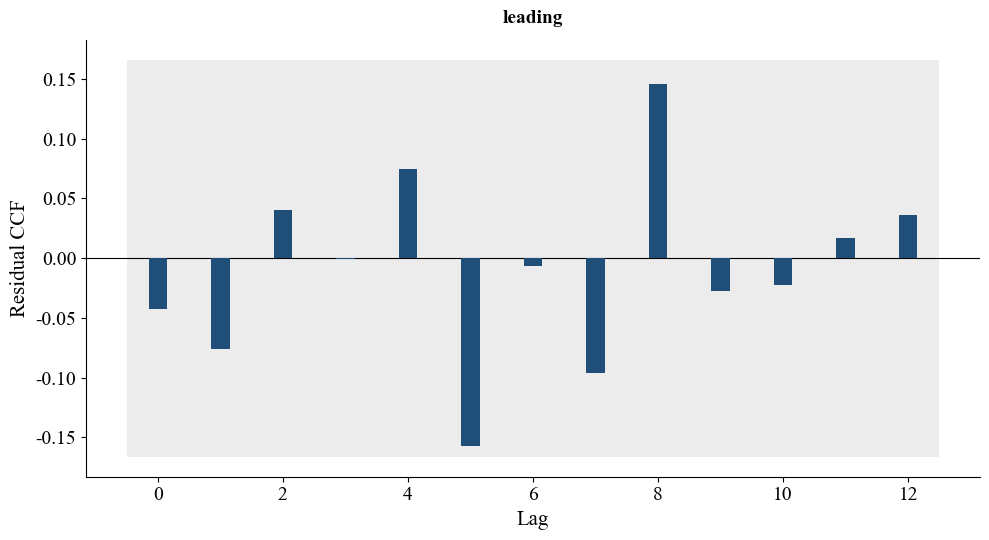

In [9]:
# Model testing - CCF
  # 1. 对同一段 leading 数据拟合预白化模型
input_model = tsmd.SARIMAX(
      df["leading"],          # 必须与RDL模型使用完全相同的140期数据
      order=(0, 1, 1),
      trend="n",              # 教材的 ΔX_t 方程没有常数
      missing="raise",
  ).fit(
      method="bfgs",
      maxiter=300,
      require_convergence=True,
  )

# print(input_model.summary())

  # 2. 最终RDL残差与输入模型新息的交叉相关
ccf_result = result.residual_ccf_test(
      {"leading": input_model},
      lags=12,
      alpha=0.05,
)

print(ccf_result.summary())
print("---------------")
print(ccf_result.tests)
ccf_result.plot_test()

In [29]:
np.sqrt(0.0574)

np.float64(0.2395829710142188)